In [5]:
# Importando o arquivo de dados insurance.csv e verificando as primeiras linhas


import pandas as pd

import warnings
warnings.filterwarnings('ignore')

insurance_df = pd.read_csv('insurance.csv')
print(insurance_df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [6]:
# Verificando número de linhas de colunas

insurance_df.shape

(1338, 7)

In [7]:
# Verificanco os tipos de dados

insurance_df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [8]:
# Identificando colunas do tipo 'object'
object_cols = insurance_df.select_dtypes(include='object').columns

# Convertendo colunas 'object' para 'category'
for col in object_cols:
    insurance_df[col] = insurance_df[col].astype('category')

print("Colunas convertidas para 'category':", object_cols.tolist())


Colunas convertidas para 'category': ['sex', 'smoker', 'region']


In [9]:
# Verificando os tipos de dados após a conversão
insurance_df.dtypes

age            int64
sex         category
bmi          float64
children       int64
smoker      category
region      category
charges      float64
dtype: object

In [10]:
# Verificando duplicatas
duplicate_rows = insurance_df[insurance_df.duplicated()]

print(f"Número de linhas duplicadas: {duplicate_rows.shape[0]}")

if not duplicate_rows.empty:
    print("As linhas duplicadas são:")
    print(duplicate_rows)

Número de linhas duplicadas: 1
As linhas duplicadas são:
     age   sex    bmi  children smoker     region    charges
581   19  male  30.59         0     no  northwest  1639.5631


In [11]:
# Removendo linhas duplicadas, mantendo a primeira ocorrência
insurance_df.drop_duplicates(inplace=True, keep='first')

print(f"Número de linhas após remover duplicatas: {insurance_df.shape[0]}")

Número de linhas após remover duplicatas: 1337


In [12]:
# Verificando novamente por duplicatas para confirmar a remoção
duplicate_rows_after_drop = insurance_df[insurance_df.duplicated()]
print(f"Número de linhas duplicadas após remoção: {duplicate_rows_after_drop.shape[0]}")

Número de linhas duplicadas após remoção: 0


In [13]:
# Verificando valores ausentes por linha
print('Valores faltantes por coluna:')
print(insurance_df.isnull().sum())

Valores faltantes por coluna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [14]:
# Outra forma de verificar, agora por coluna
print('Valores faltantes por coluna usando isna():')
print(insurance_df.isna().sum())

Valores faltantes por coluna usando isna():
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [ ]:
# Verificando erros de tipo em colunas numéricas
print('Verificando colunas numéricas para valores não numéricos:')

for col in ['age', 'bmi', 'children', 'charges']:
    # Tenta converter a coluna para numérico, transformando erros em NaN
    non_numeric_values = pd.to_numeric(insurance_df[col], errors='coerce').isnull().sum()
    if non_numeric_values > 0:
        print(f"  - Coluna '{col}': {non_numeric_values} valores não numéricos encontrados.")
    else:
        print(f"  - Coluna '{col}': Nenhum valor não numérico encontrado.")


Verificando colunas numéricas para valores não numéricos:
  - Coluna 'age': Nenhum valor não numérico encontrado.
  - Coluna 'bmi': Nenhum valor não numérico encontrado.
  - Coluna 'children': Nenhum valor não numérico encontrado.
  - Coluna 'charges': Nenhum valor não numérico encontrado.


In [16]:
# Verificando valores em colunas categóricas
print('\nVerificando valores únicos em colunas categóricas:')

for col in ['sex', 'smoker', 'region']:
    print(f"  - Coluna '{col}':")
    display(insurance_df[col].value_counts())
    print("\n")


Verificando valores únicos em colunas categóricas:
  - Coluna 'sex':


sex
male      675
female    662
Name: count, dtype: int64



  - Coluna 'smoker':


smoker
no     1063
yes     274
Name: count, dtype: int64



  - Coluna 'region':


region
southeast    364
southwest    325
northeast    324
northwest    324
Name: count, dtype: int64

In [17]:
import numpy as np

# Redefinindo as listas de colunas numéricas e categóricas
numerical_cols = insurance_df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = insurance_df.select_dtypes(include='category').columns.tolist()

print("Colunas Numéricas:", numerical_cols)
print("Colunas Categóricas:", categorical_cols)

Colunas Numéricas: ['age', 'bmi', 'children', 'charges']
Colunas Categóricas: ['sex', 'smoker', 'region']


In [18]:
# Gerando estatísticas descritivas apenas para colunas numéricas
print('Estatísticas Descritivas para Variáveis Numéricas:')
display(insurance_df[numerical_cols].describe())

Estatísticas Descritivas para Variáveis Numéricas:


,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [19]:
# Gerando estatísticas descritivas apenas para colunas categóricas
print('Estatísticas Descritivas para Variáveis Categóricas:')
display(insurance_df[categorical_cols].describe())

Estatísticas Descritivas para Variáveis Categóricas:


,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


In [20]:
# Exibindo todos os valores únicos para cada variável categórica
print('Valores únicos para cada variável categórica:')

for col in categorical_cols:
    print(f"\n--- Coluna '{col}' ---")
    display(insurance_df[col].value_counts())

Valores únicos para cada variável categórica:

--- Coluna 'sex' ---


sex
male      675
female    662
Name: count, dtype: int64


--- Coluna 'smoker' ---


smoker
no     1063
yes     274
Name: count, dtype: int64


--- Coluna 'region' ---


region
southeast    364
southwest    325
northeast    324
northwest    324
Name: count, dtype: int64

In [21]:
# Calculando Média e Mediana para variáveis numéricas
print('Média das Variáveis Numéricas:')
display(insurance_df[numerical_cols].mean())

print('\nMediana das Variáveis Numéricas:')
display(insurance_df[numerical_cols].median())

Média das Variáveis Numéricas:


age            39.222139
bmi            30.663452
children        1.095737
charges     13279.121487
dtype: float64


Mediana das Variáveis Numéricas:


age           39.0000
bmi           30.4000
children       1.0000
charges     9386.1613
dtype: float64

In [22]:
# Calculando a Moda para todas as variáveis (numéricas e categóricas)
print('Moda de Todas as Variáveis:')

# A moda pode ter múltiplos valores, então display() é ideal para visualizá-los.
for col in insurance_df.columns:
    print(f"\n--- Moda da Coluna '{col}' ---")
    display(insurance_df[col].mode())

Moda de Todas as Variáveis:

--- Moda da Coluna 'age' ---


0    18
Name: age, dtype: int64


--- Moda da Coluna 'sex' ---


0    male
Name: sex, dtype: category
Categories (2, str): ['female', 'male']


--- Moda da Coluna 'bmi' ---


...

0    no
Name: smoker, dtype: category
Categories (2, str): ['no', 'yes']


--- Moda da Coluna 'region' ---


0    southeast
Name: region, dtype: category
Categories (4, str): ['northeast', 'northwest', 'southeast', 'southwest']


--- Moda da Coluna 'charges' ---


0        1121.87390
1        1131.50660
2        1135.94070
3        1136.39940
4        1137.01100
           ...     
1332    55135.40209
1333    58571.07448
1334    60021.39897
1335    62592.87309
1336    63770.42801
Name: charges, Length: 1337, dtype: float64

In [23]:
import numpy as np

# Calculando o número de classes usando a Regra de Sturges
k = int(1 + 3.322 * np.log10(len(insurance_df)))

print(f"Número de classes (Regra de Sturges): {k}")

# Gerando a tabela de distribuição de frequência para 'charges'
# Definindo os bins
charges_bins = pd.cut(insurance_df['charges'], bins=k, include_lowest=True)

# Calculando a frequência absoluta e relativa
freq_abs = charges_bins.value_counts().sort_index()
freq_rel = charges_bins.value_counts(normalize=True).sort_index() * 100

# Criando o DataFrame da tabela de distribuição
distribution_table_charges = pd.DataFrame({
    'Frequência Absoluta': freq_abs,
    'Frequência Relativa (%)': freq_rel
})

# Calculando a frequência acumulada absoluta e relativa
distribution_table_charges['Frequência Acumulada'] = distribution_table_charges['Frequência Absoluta'].cumsum()
distribution_table_charges['Frequência Relativa Acumulada (%)'] = distribution_table_charges['Frequência Relativa (%)'].cumsum()

print("\nTabela de Distribuição de Frequência para 'charges':")
display(distribution_table_charges)

Número de classes (Regra de Sturges): 11

Tabela de Distribuição de Frequência para 'charges':


,Frequência Absoluta,Frequência Relativa (%),Frequência Acumulada,Frequência Relativa Acumulada (%)
charges,,,,
"(1059.224, 6817.197]",491,36.724009,491,36.724009
"(6817.197, 12512.52]",383,28.646223,874,65.370232
"(12512.52, 18207.843]",152,11.368736,1026,76.738968
"(18207.843, 23903.166]",93,6.955871,1119,83.694839
"(23903.166, 29598.489]",56,4.188482,1175,87.883321
"(29598.489, 35293.813]",32,2.393418,1207,90.276739
"(35293.813, 40989.136]",61,4.562453,1268,94.839192
"(40989.136, 46684.459]",42,3.141361,1310,97.980553
"(46684.459, 52379.782]",21,1.570681,1331,99.551234


In [24]:
import numpy as np

# Calculando o número de classes usando a Regra de Freedman-Diaconis
# IQR (Interquartile Range)
Q1 = insurance_df['charges'].quantile(0.25)
Q3 = insurance_df['charges'].quantile(0.75)
IQR = Q3 - Q1

# Largura do bin (bin width)
bin_width_fd = 2 * IQR / (len(insurance_df)**(1/3))

# Número de classes
k_fd = int(np.ceil((insurance_df['charges'].max() - insurance_df['charges'].min()) / bin_width_fd))

print(f"Número de classes (Regra de Freedman-Diaconis): {k_fd}")

# Gerando a tabela de distribuição de frequência para 'charges' com Freedman-Diaconis
charges_bins_fd = pd.cut(insurance_df['charges'], bins=k_fd, include_lowest=True)

freq_abs_fd = charges_bins_fd.value_counts().sort_index()
freq_rel_fd = charges_bins_fd.value_counts(normalize=True).sort_index() * 100

distribution_table_charges_fd = pd.DataFrame({
    'Frequência Absoluta': freq_abs_fd,
    'Frequência Relativa (%)': freq_rel_fd
})

distribution_table_charges_fd['Frequência Acumulada'] = distribution_table_charges_fd['Frequência Absoluta'].cumsum()
distribution_table_charges_fd['Frequência Relativa Acumulada (%)'] = distribution_table_charges_fd['Frequência Relativa (%)'].cumsum()

print("\nTabela de Distribuição de Frequência para 'charges' (Freedman-Diaconis):")
display(distribution_table_charges_fd)


Número de classes (Regra de Freedman-Diaconis): 29

Tabela de Distribuição de Frequência para 'charges' (Freedman-Diaconis):


,Frequência Absoluta,Frequência Relativa (%),Frequência Acumulada,Frequência Relativa Acumulada (%)
charges,,,,
"(1059.224, 3282.169]",214,16.005984,214,16.005984
"(3282.169, 5442.464]",182,13.612565,396,29.618549
"(5442.464, 7602.759]",151,11.293942,547,40.912491
"(7602.759, 9763.054]",147,10.994764,694,51.907255
"(9763.054, 11923.349]",145,10.845176,839,62.752431
"(11923.349, 14083.644]",112,8.376963,951,71.129394
"(14083.644, 16243.939]",45,3.365744,996,74.495138
"(16243.939, 18404.234]",36,2.692595,1032,77.187734
"(18404.234, 20564.529]",41,3.066567,1073,80.254301


## Comparação das Tabelas de Distribuição de Frequência

Aqui estão as duas tabelas de distribuição de frequência para a variável 'charges' para comparação:

### 1. Tabela usando a Regra de Sturges (Número de Classes: 11)


In [25]:
display(distribution_table_charges)

,Frequência Absoluta,Frequência Relativa (%),Frequência Acumulada,Frequência Relativa Acumulada (%)
charges,,,,
"(1059.224, 6817.197]",491,36.724009,491,36.724009
"(6817.197, 12512.52]",383,28.646223,874,65.370232
"(12512.52, 18207.843]",152,11.368736,1026,76.738968
"(18207.843, 23903.166]",93,6.955871,1119,83.694839
"(23903.166, 29598.489]",56,4.188482,1175,87.883321
"(29598.489, 35293.813]",32,2.393418,1207,90.276739
"(35293.813, 40989.136]",61,4.562453,1268,94.839192
"(40989.136, 46684.459]",42,3.141361,1310,97.980553
"(46684.459, 52379.782]",21,1.570681,1331,99.551234


### 2. Tabela usando a Regra de Freedman-Diaconis (Número de Classes: calculado acima)

Observe como o número de classes e a granularidade dos intervalos diferem entre as duas regras, impactando a forma como a distribuição dos 'charges' é visualizada.

In [26]:
display(distribution_table_charges_fd)

,Frequência Absoluta,Frequência Relativa (%),Frequência Acumulada,Frequência Relativa Acumulada (%)
charges,,,,
"(1059.224, 3282.169]",214,16.005984,214,16.005984
"(3282.169, 5442.464]",182,13.612565,396,29.618549
"(5442.464, 7602.759]",151,11.293942,547,40.912491
"(7602.759, 9763.054]",147,10.994764,694,51.907255
"(9763.054, 11923.349]",145,10.845176,839,62.752431
"(11923.349, 14083.644]",112,8.376963,951,71.129394
"(14083.644, 16243.939]",45,3.365744,996,74.495138
"(16243.939, 18404.234]",36,2.692595,1032,77.187734
"(18404.234, 20564.529]",41,3.066567,1073,80.254301


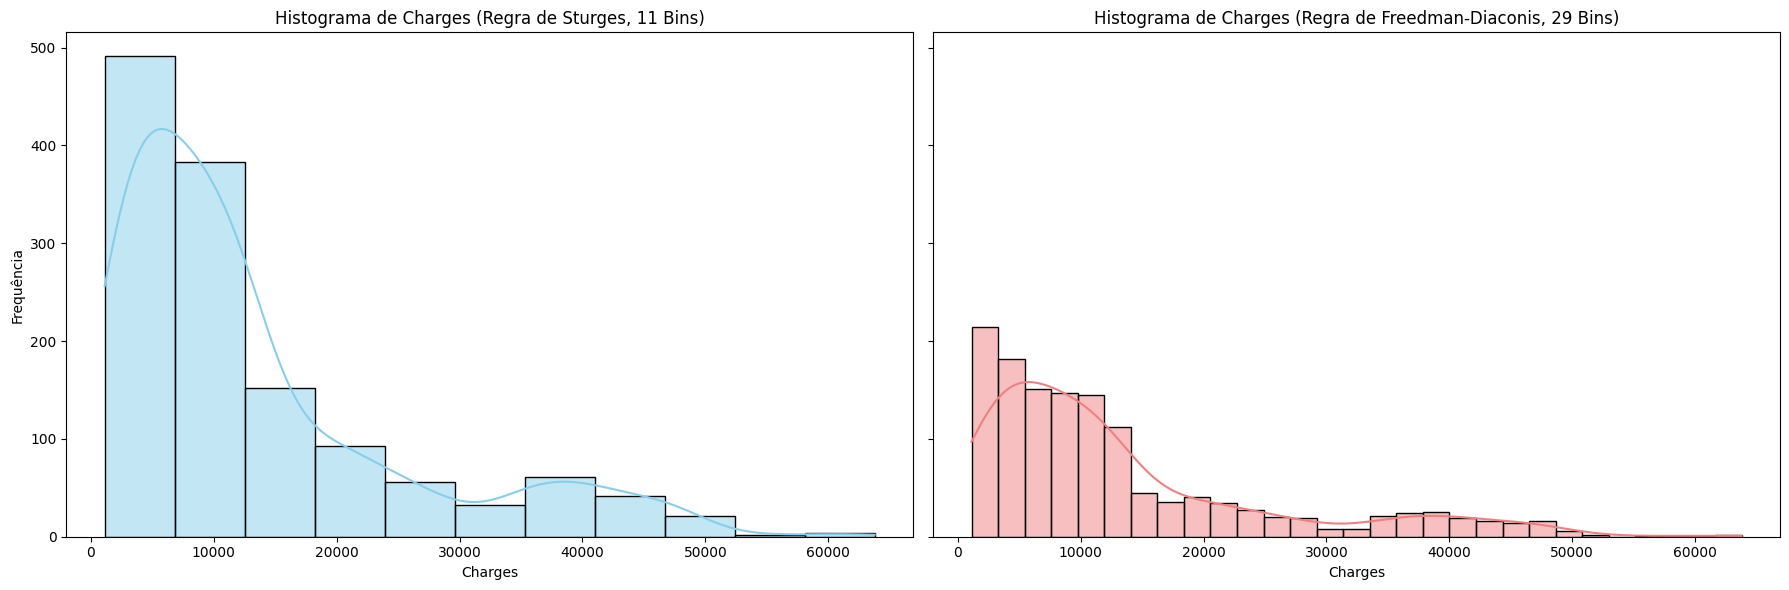

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criando dois subplots para comparar os histogramas
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Histograma usando a Regra de Sturges
sns.histplot(insurance_df['charges'], bins=k, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title(f'Histograma de Charges (Regra de Sturges, {k} Bins)')
axes[0].set_xlabel('Charges')
axes[0].set_ylabel('Frequência')

# Histograma usando a Regra de Freedman-Diaconis
sns.histplot(insurance_df['charges'], bins=k_fd, kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title(f'Histograma de Charges (Regra de Freedman-Diaconis, {k_fd} Bins)')
axes[1].set_xlabel('Charges')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

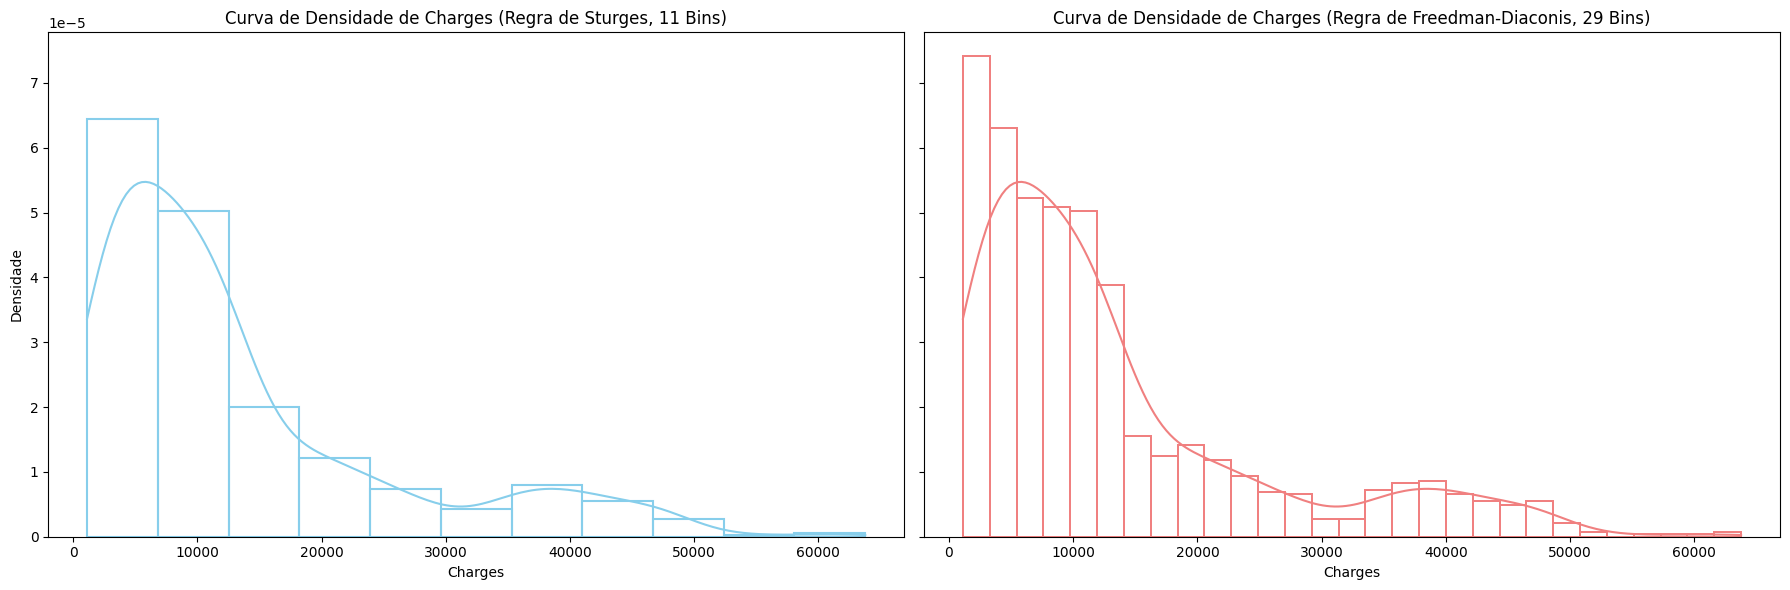

In [28]:
# Agora uma estimativa da função de densidade de probabilidade
# (kde=True; stat='density' - área total abaixo da curva é 1)

import matplotlib.pyplot as plt
import seaborn as sns

# Criando dois subplots para comparar as curvas de densidade
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Curva de Densidade usando a Regra de Sturges
sns.histplot(insurance_df['charges'], bins=k, kde=True, ax=axes[0], color='skyblue', stat='density', fill=False)
axes[0].set_title(f'Curva de Densidade de Charges (Regra de Sturges, {k} Bins)')
axes[0].set_xlabel('Charges')
axes[0].set_ylabel('Densidade')

# Curva de Densidade usando a Regra de Freedman-Diaconis
sns.histplot(insurance_df['charges'], bins=k_fd, kde=True, ax=axes[1], color='lightcoral', stat='density', fill=False)
axes[1].set_title(f'Curva de Densidade de Charges (Regra de Freedman-Diaconis, {k_fd} Bins)')
axes[1].set_xlabel('Charges')
axes[1].set_ylabel('Densidade')

plt.tight_layout()
plt.show()

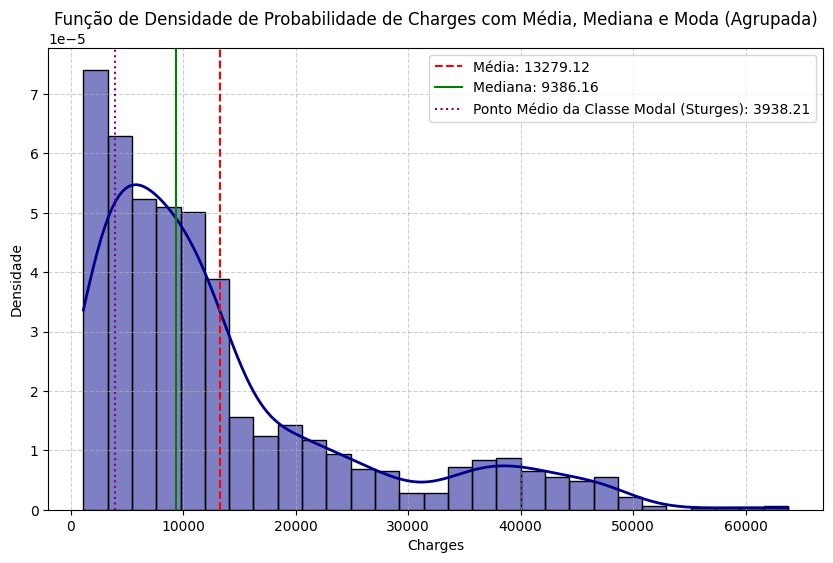


Valores Calculados:
Média de Charges: 13279.12
Mediana de Charges: 9386.16
Ponto Médio da Classe Modal (Sturges): 3938.21


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculando a média, mediana e moda de 'charges'
mean_charges = insurance_df['charges'].mean()
median_charges = insurance_df['charges'].median()

# Para a moda de dados agrupados (Regra de Sturges):
# A classe modal é (1059.224, 6817.197] (identificada anteriormente pela maior frequência absoluta)
midpoint_modal_class = (1059.224 + 6817.197) / 2

# Criando o plot da função de densidade de probabilidade
plt.figure(figsize=(10, 6))
sns.histplot(insurance_df['charges'], kde=True, stat='density', color='darkblue', line_kws={'linewidth': 2})

# Adicionando a média, mediana e moda ao gráfico
plt.axvline(mean_charges, color='red', linestyle='--', label=f'Média: {mean_charges:.2f}')
plt.axvline(median_charges, color='green', linestyle='-', label=f'Mediana: {median_charges:.2f}')
plt.axvline(midpoint_modal_class, color='purple', linestyle=':', label=f'Ponto Médio da Classe Modal (Sturges): {midpoint_modal_class:.2f}')

plt.title('Função de Densidade de Probabilidade de Charges com Média, Mediana e Moda (Agrupada)')
plt.xlabel('Charges')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"\nValores Calculados:")
print(f"Média de Charges: {mean_charges:.2f}")
print(f"Mediana de Charges: {median_charges:.2f}")
print(f"Ponto Médio da Classe Modal (Sturges): {midpoint_modal_class:.2f}")


### Perceba que temos uma "Curva assimétrica a direita" ou uma "Curva positivamente assimétrica" (são formas diferentes de dizer a mesma coisa) ###

### 1. Estatísticas de 'Charges' por Sexo

Primeiro, vamos calcular o valor mínimo, valor máximo, média, mediana e a moda (calculada como o ponto médio da classe modal pela Regra de Sturges) para a variável 'charges', separadamente para cada sexo.

In [30]:
import pandas as pd
import numpy as np

# Dicionário para armazenar os resultados das estatísticas por sexo
stats_by_sex = {}

# Iterar sobre as categorias de sexo
for sex_category in insurance_df['sex'].unique():
    subset_charges = insurance_df[insurance_df['sex'] == sex_category]['charges']

    # Calcular estatísticas básicas
    min_val = subset_charges.min()
    max_val = subset_charges.max()
    mean_val = subset_charges.mean()
    median_val = subset_charges.median()

    # Calcular o número de classes pela Regra de Sturges para o subset
    k_sturges = int(1 + 3.322 * np.log10(len(subset_charges)))
    if k_sturges < 2: # Garantir pelo menos 2 classes para evitar erros com pd.cut
        k_sturges = 2

    # Gerar bins e calcular a classe modal
    charges_bins = pd.cut(subset_charges, bins=k_sturges, include_lowest=True)

    # Encontrar o ponto médio da classe modal
    if not charges_bins.value_counts().empty:
        modal_class = charges_bins.value_counts().idxmax()
        midpoint_modal_class = (modal_class.left + modal_class.right) / 2
    else:
        midpoint_modal_class = np.nan # Se não houver dados para formar bins

    # Armazenar os resultados
    stats_by_sex[sex_category] = {
        'Mínimo': min_val,
        'Máximo': max_val,
        'Média': mean_val,
        'Mediana': median_val,
        'Moda Agrupada (Sturges)': midpoint_modal_class
    }

# Converter o dicionário para um DataFrame e exibir
stats_df = pd.DataFrame(stats_by_sex).T
print("Estatísticas de 'Charges' por Sexo:")
display(stats_df)


Estatísticas de 'Charges' por Sexo:


,Mínimo,Máximo,Média,Mediana,Moda Agrupada (Sturges)
female,1607.5101,63770.42801,12569.578844,9412.9625,4684.574
male,1121.8739,62592.87309,13974.998864,9377.9047,4164.688


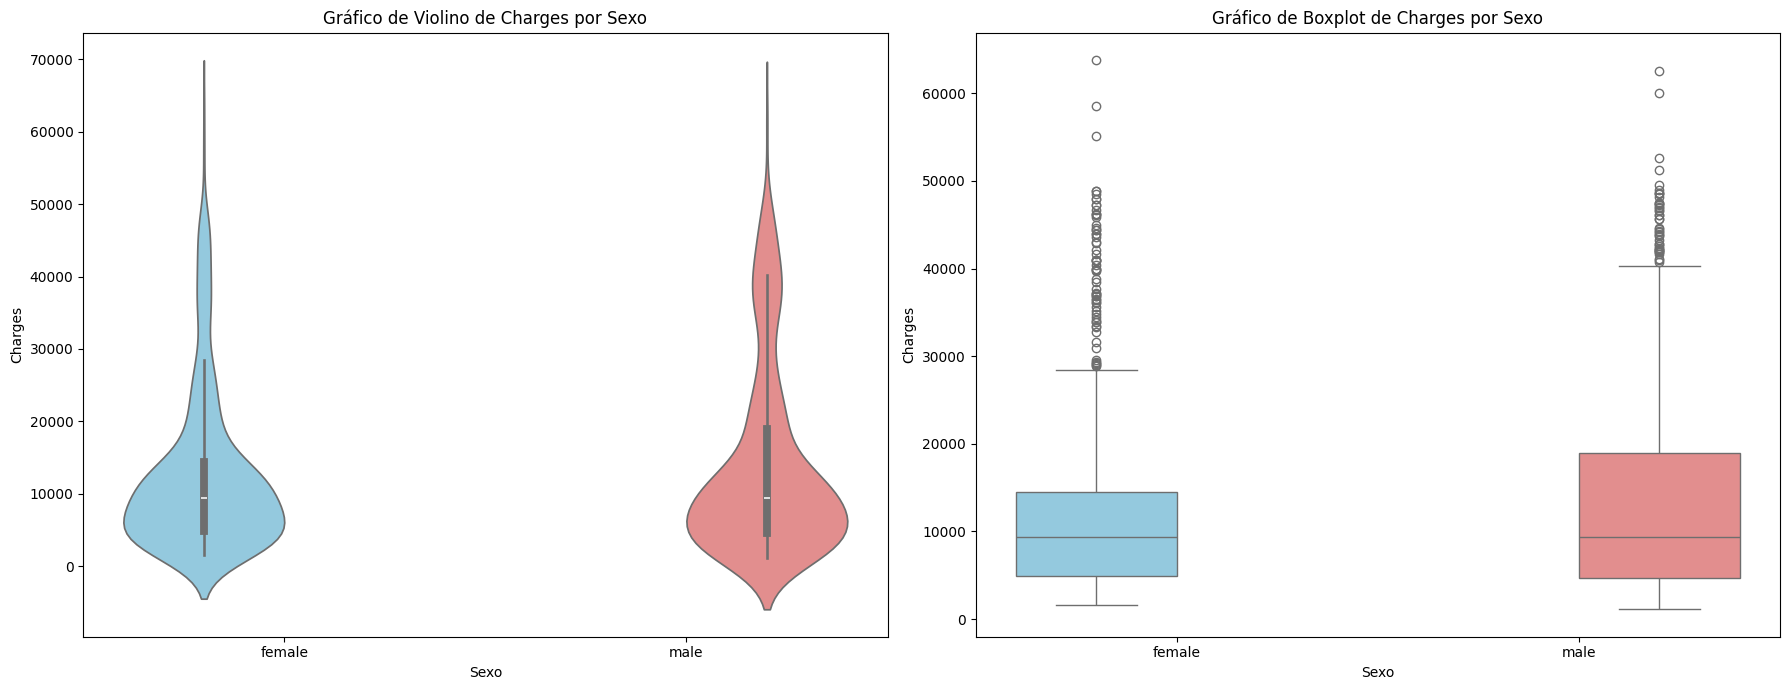

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criando dois subplots para os gráficos
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico de Violino para 'charges' por 'sex'
sns.violinplot(x='sex', y='charges', data=insurance_df, ax=axes[0], hue='sex', palette={'female': 'skyblue', 'male': 'lightcoral'}, legend=False)
axes[0].set_title('Gráfico de Violino de Charges por Sexo')
axes[0].set_xlabel('Sexo')
axes[0].set_ylabel('Charges')

# Gráfico de Boxplot para 'charges' por 'sex'
sns.boxplot(x='sex', y='charges', data=insurance_df, ax=axes[1], hue='sex', palette={'female': 'skyblue', 'male': 'lightcoral'}, legend=False)
axes[1].set_title('Gráfico de Boxplot de Charges por Sexo')
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Charges') # Manter para clareza, mesmo se compartilhado

plt.tight_layout()
plt.show()

### 2. Funções de Densidade de Probabilidade de 'Charges' por Sexo

Agora, vamos plotar as funções de densidade de probabilidade para 'charges' para cada sexo, marcando a média, mediana e o ponto médio da classe modal (agrupada por Sturges) em cada gráfico.

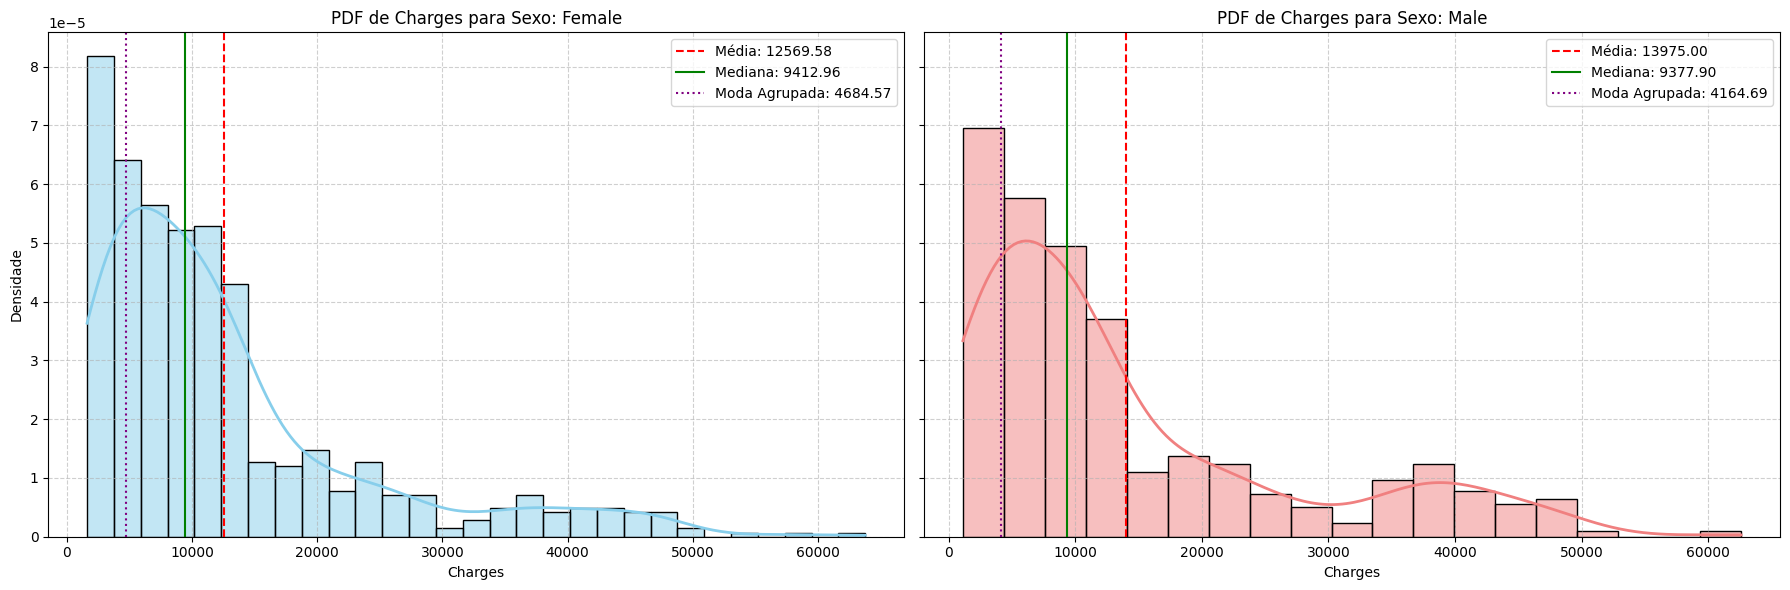


Valores Calculados de Média, Mediana e Moda Agrupada de 'Charges' por Sexo:

--- Female ---
Média: 12569.58
Mediana: 9412.96
Moda Agrupada (Sturges): 4684.57

--- Male ---
Média: 13975.00
Mediana: 9377.90
Moda Agrupada (Sturges): 4164.69


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Criando dois subplots para as curvas de densidade por sexo
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True) # Compartilhar o eixo Y para melhor comparação

sex_categories = insurance_df['sex'].unique()

for i, sex_category in enumerate(sex_categories):
    subset_charges = insurance_df[insurance_df['sex'] == sex_category]['charges']

    # Recalcular as estatísticas para o subset atual (para garantir que os valores no gráfico correspondam)
    mean_val = subset_charges.mean()
    median_val = subset_charges.median()

    # Calcular a moda agrupada para o subset atual
    k_sturges = int(1 + 3.322 * np.log10(len(subset_charges)))
    if k_sturges < 2:
        k_sturges = 2

    charges_bins = pd.cut(subset_charges, bins=k_sturges, include_lowest=True)
    if not charges_bins.value_counts().empty:
        modal_class = charges_bins.value_counts().idxmax()
        midpoint_modal_class = (modal_class.left + modal_class.right) / 2
    else:
        midpoint_modal_class = np.nan

    # Plotar a função de densidade de probabilidade
    color = 'skyblue' if sex_category == 'female' else 'lightcoral'
    sns.histplot(subset_charges, kde=True, stat='density', color=color, line_kws={'linewidth': 2}, ax=axes[i])

    # Adicionar média, mediana e moda agrupada ao gráfico
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Média: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='-', label=f'Mediana: {median_val:.2f}')
    if not np.isnan(midpoint_modal_class):
        axes[i].axvline(midpoint_modal_class, color='purple', linestyle=':', label=f'Moda Agrupada: {midpoint_modal_class:.2f}')

    axes[i].set_title(f'PDF de Charges para Sexo: {sex_category.capitalize()}')
    axes[i].set_xlabel('Charges')
    axes[i].set_ylabel('Densidade' if i == 0 else '') # Apenas o primeiro gráfico terá rótulo no eixo Y
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("\nValores Calculados de Média, Mediana e Moda Agrupada de 'Charges' por Sexo:")
for sex_category in sex_categories:
    subset_charges = insurance_df[insurance_df['sex'] == sex_category]['charges']
    mean_val = subset_charges.mean()
    median_val = subset_charges.median()

    k_sturges = int(1 + 3.322 * np.log10(len(subset_charges)))
    if k_sturges < 2: k_sturges = 2
    charges_bins = pd.cut(subset_charges, bins=k_sturges, include_lowest=True)
    if not charges_bins.value_counts().empty:
        modal_class = charges_bins.value_counts().idxmax()
        midpoint_modal_class = (modal_class.left + modal_class.right) / 2
    else:
        midpoint_modal_class = np.nan

    print(f"\n--- {sex_category.capitalize()} ---")
    print(f"Média: {mean_val:.2f}")
    print(f"Mediana: {median_val:.2f}")
    print(f"Moda Agrupada (Sturges): {midpoint_modal_class:.2f}")


In [33]:
# Calculando a diferença percentual entre homens e mulheres para média, mediana e moda agrupada de 'charges'

# Extraindo os valores para mulheres
mean_female = stats_df.loc['female', 'Média']
median_female = stats_df.loc['female', 'Mediana']
mode_grouped_female = stats_df.loc['female', 'Moda Agrupada (Sturges)']

# Extraindo os valores para homens
mean_male = stats_df.loc['male', 'Média']
median_male = stats_df.loc['male', 'Mediana']
mode_grouped_male = stats_df.loc['male', 'Moda Agrupada (Sturges)']

# Calculando a diferença percentual (assumindo a diferença em relação ao valor feminino como base)
# Diferença percentual = ((Valor_Masculino - Valor_Feminino) / Valor_Feminino) * 100

diff_mean_perc = ((mean_male - mean_female) / mean_female) * 100
diff_median_perc = ((median_male - median_female) / median_female) * 100
diff_mode_grouped_perc = ((mode_grouped_male - mode_grouped_female) / mode_grouped_female) * 100

print("Diferença Percentual (Masculino vs. Feminino) para 'Charges':")
print(f"- Média: {diff_mean_perc:.2f}%")
print(f"- Mediana: {diff_median_perc:.2f}%")
print(f"- Moda Agrupada (Sturges): {diff_mode_grouped_perc:.2f}%")

Diferença Percentual (Masculino vs. Feminino) para 'Charges':
- Média: 11.18%
- Mediana: -0.37%
- Moda Agrupada (Sturges): -11.10%


Pode-se dizer que, em média, os homens pagam mais pelos 'charges'. A média de 'charges' para os homens é cerca de 11.18% maior que para as mulheres.

No entanto, é importante notar que a mediana é muito similar para ambos os sexos (a diferença é de apenas -0.37%, o que é insignificante na prática) e a moda agrupada é até um pouco menor para os homens (-11.10%).

Isso sugere que:

A maioria dos homens têm 'charges' que são semelhantes ou até ligeiramente menores do que os da maioria das mulheres (indicado pela mediana e moda).
A média mais alta para os homens é provavelmente impulsionada por um grupo menor de homens que têm 'charges' significativamente mais altos (provavelmente fumantes), puxando a média para cima, mesmo que o valor típico ou mais frequente não seja tão diferente, isto porque as mulheres tem despesas com ginecologia e obstetrícia.

In [34]:
# Calculando a assimetria (skewness) e curtose (kurtosis) para 'charges' por sexo

skew_kurt_by_sex = insurance_df.groupby('sex')['charges'].agg([
    ('Assimetria', lambda x: x.skew()),
    ('Curtose', lambda x: x.kurt())
])

print("Indicadores de Assimetria e Curtose de 'Charges' por Sexo:")
display(skew_kurt_by_sex)

Indicadores de Assimetria e Curtose de 'Charges' por Sexo:


,Assimetria,Curtose
sex,,
female,1.728944,2.754058
male,1.334556,0.813741


A **assimetria (Skewness)** mede o grau de distorção de uma distribuição. Valores positivos indicam uma assimetria à direita (cauda mais longa à direita), enquanto valores negativos indicam assimetria à esquerda. Quanto maior o valor absoluto, maior a assimetria. Calculado pelo terceiro momento central padronizado:
Skewness (g1) = [1/n * Σ(xi - μ)³] / σ³

Em que:

n = o número de observações (tamanho da amostra).
xi = valores individuais dos dados.
μ (mi) = média da amostra.
σ (sigma) = desvio padrão da amostra.
Σ = soma de todos os valores.

Para as mulheres (Female), a assimetria calculada é de 1.728944. Para os homens (Male), a assimetria calculada é de 1.334556.

Ambos os valores são positivos, o que nos indica o seguinte:

Assimetria Positiva (ou Assimétrica à Direita): Uma assimetria positiva significa que a cauda da distribuição é mais longa e mais "pesada" à direita do pico. Em termos práticos, isso quer dizer que há um maior número de observações com valores relativamente baixos, mas também existem algumas observações com valores significativamente mais altos que puxam a média para a direita da mediana e da moda.

No contexto dos 'charges' (custos de seguro), isso implica que a maioria das pessoas (tanto homens quanto mulheres) têm custos de seguro mais baixos, mas há um subgrupo de indivíduos com custos muito mais elevados, que estendem a distribuição para a direita. Essa é uma característica comum em dados de custos e salários.

Comparação entre Sexos:
A assimetria para as mulheres (1.73) é ligeiramente maior do que para os homens (1.33). Embora ambos sejam positivamente assimétricos, o valor mais alto para as mulheres sugere que a cauda direita de sua distribuição de 'charges' é um pouco mais pronunciada ou que os valores mais altos são relativamente mais extremos para as mulheres, em comparação com a distribuição dos homens. Isso corrobora a ideia de que, mesmo com uma média mais alta para homens, a distribuição feminina pode ter alguns valores excepcionalmente altos puxando a assimetria para cima.
Em resumo, para ambos os sexos, a maioria dos 'charges' está concentrada em valores mais baixos, mas existem casos de custos muito altos que distorcem a distribuição, com essa distorção sendo um pouco mais acentuada no grupo feminino.

A **curtose (Kurtosis)** mede o 'achatamento' da distribuição e a 'pesadez' das caudas em relação a uma distribuição normal.

Curtose (Fisher's Kurtosis) no Pandas (.kurt())

Fórmula: A função .kurt() calcula o quarto momento central padronizado e, por padrão (fisher=True), subtrai 3 dele.

Excesso de Curtose = ([1/n * Σ(xi - μ)⁴] / σ⁴) - 3
Interpretação para a Curtose no Pandas (.kurt()):

Valor = 0: A distribuição é mesocúrtica, ou seja, tem o mesmo grau de 'achatamento' e 'pesadez nas caudas' que uma distribuição normal.

Valor > 0 (Positivo): A distribuição é leptocúrtica. Isso significa que ela é mais pontiaguda no pico e possui caudas mais pesadas (mais valores extremos, outliers) do que uma distribuição normal.

Valor < 0 (Negativo): A distribuição é platicúrtica. Isso significa que ela é mais achatada no pico e possui caudas mais leves (menos valores extremos) do que uma distribuição normal.
Reinterpretação Definitiva dos Seus Resultados
Dado que você calculou com lambda x: x.kurt() e obteve:

Para mulheres (Female): 2.75
Para homens (Male): 0.81
Ambos os valores são positivos.

Isso significa que, para ambos os sexos, a distribuição dos 'charges' é leptocúrtica.

Implicação: As distribuições dos 'charges' para homens e mulheres são mais pontiagudas à esquerda e têm caudas mais pesadas do que o esperado para uma distribuição normal. Isso sugere que existe uma concentração maior de dados em torno da moda (tornando o pico mais alto) e, ao mesmo tempo, uma maior probabilidade de ocorrência de valores extremos (que podem talvez ser outliers) nas 'caudas' da distribuição.

Comparação entre os Sexos: A curtose para as mulheres (2.75) é significativamente maior que a dos homens (0.81). Isso indica que a distribuição dos 'charges' para as mulheres é ainda mais leptocúrtica do que a dos homens, ou seja, ela tem um pico mais acentuado e caudas ainda mais pesadas, com uma maior proporção de valores extremos, em comparação com a distribuição masculina. Isso pode ser um indicativo de que as despesas mais altas são proporcionalmente mais 'extremas' nas mulheres do que nos homens.

In [35]:
import pandas as pd

# Calculando o desvio padrão de 'charges' por sexo
std_dev_by_sex = insurance_df.groupby('sex')['charges'].std()

print("Desvio Padrão de 'Charges' por Sexo:")
display(std_dev_by_sex)

Desvio Padrão de 'Charges' por Sexo:


sex
female    11128.703801
male      12971.958663
Name: charges, dtype: float64

### Interpretação do Desvio Padrão por Sexo

O desvio padrão é uma medida de dispersão que indica o quanto os valores de um conjunto de dados se afastam da média. Um desvio padrão alto significa que os dados estão mais espalhados (maior variabilidade), enquanto um desvio padrão baixo indica que os dados estão mais concentrados em torno da média (menor variabilidade).

Ao comparar os desvios padrão entre os sexos, podemos entender qual grupo tem uma maior dispersão nos valores de 'charges'.

Desvio Padrão:

Mulheres: 11128.70
Homens: 12971.96

O desvio padrão dos 'charges' para os homens (12971.96) é maior do que para as mulheres (11128.70). Isso indica que há uma maior dispersão ou variabilidade nos valores de 'charges' entre os homens em comparação com as mulheres. Ou seja, os custos de seguro dos homens tendem a variar mais em torno da média do que os das mulheres.

In [36]:
# Extraindo os valores do desvio padrão para mulheres e homens
std_dev_female = std_dev_by_sex.loc['female']
std_dev_male = std_dev_by_sex.loc['male']

# Calculando a diferença percentual (homens vs. mulheres)
# Diferença percentual = ((Valor_Masculino - Valor_Feminino) / Valor_Feminino) * 100
diff_std_dev_perc = ((std_dev_male - std_dev_female) / std_dev_female) * 100

print("Diferença Percentual (Masculino vs. Feminino) para o Desvio Padrão de 'Charges':")
print(f"- Desvio Padrão: {diff_std_dev_perc:.2f}%")

Diferença Percentual (Masculino vs. Feminino) para o Desvio Padrão de 'Charges':
- Desvio Padrão: 16.56%
